In [10]:
import numpy as np
%load_ext autoreload
%autoreload 2
import os
os.environ["OMP_NUM_THREADS"] = "1"
from inspect import signature
from train import *
from train_config import load_config
plt.rcParams.update({'font.size': 10,
                     'font.family': 'arial',
                     'pdf.fonttype': 42,
                     'ps.fonttype': 42,
                     'savefig.dpi': 480})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


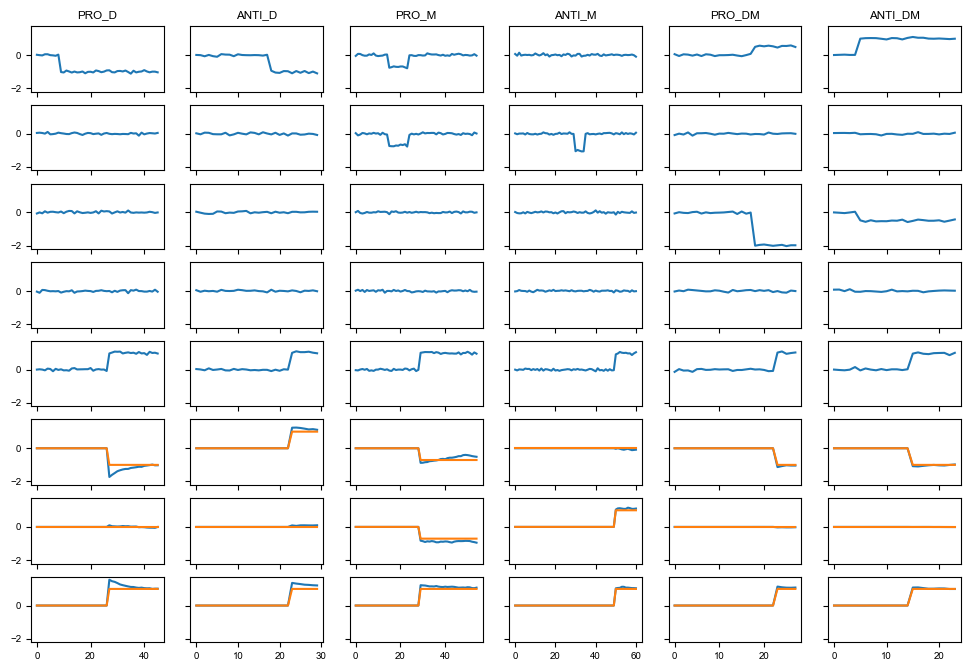

In [3]:
nonlin_str = '_relu'
task_order = 'PdAdPmAmPdmAdm'
seed = 0
save_name = f'cxtrnn_seq_v2_gating3_ioZ{nonlin_str}_{task_order}_tskm512_sd{seed}'
config = load_config(save_name)
config['retrain'] = False
####################################################
model, tr_loss_arr, ts_loss_arr, ts_perf_arr = train_cxtrnn_sequential(**config)
####################################################
# fig, axes = plt.subplots(3, 1, figsize=(4, 6), sharex=True, sharey=False)
# axes[0].plot(tr_loss_arr, color='gray')
# axes[0].set_ylabel('training loss')
# for iax in [1, 2]:
#     ts_arr = [ts_loss_arr, ts_perf_arr][iax - 1]
#     ylabel = ['test loss', 'test perf'][iax - 1]
#     for itask in range(len(config['task_list'])):
#         axes[iax].plot(ts_arr[itask], color=f'C{itask}', label=config['task_list'][itask])
#     axes[iax].legend(loc='center left', bbox_to_anchor=(1, 0.5))
#     axes[iax].set_ylabel(ylabel)
#     ymin, ymax = axes[iax].get_ylim()
#     dn_ckpt = config['num_iter'] / config['ckpt_step']
#     for itask in range(len(config['task_list']) + 1):
#         axes[iax].plot([itask * dn_ckpt + 1] * 2, [ymin, ymax], alpha=0.2, color='gray')
#     for itask in range(len(config['task_list'])):
#         axes[iax].fill_between([itask * dn_ckpt + 1, (itask + 1) * dn_ckpt + 1], ymin, ymax, color=f'C{itask}', alpha=0.1)
####################################################
dim_s = config.get('dim_s', 3)
dim_y = config.get('dim_y', 3)
if ('z_list' not in config) or (config['z_list'] is None):
    config['z_list'] = get_z_list(config['task_list'], config['epoch_type'])
# sig = signature(TaskDataset.__init__)
# klist = [p.name for p in sig.parameters.values() if p.kind == p.POSITIONAL_OR_KEYWORD]
# klist.remove('self')
# data_kwargs = {k: v for k, v in config.items() if k in klist}
####################################################
fig, axes = plt.subplots(dim_s + dim_y, len(config['task_list']),
                         figsize=(2 * len(config['task_list']), dim_s + dim_y),
                         sharey=True, sharex='col')
if len(axes.shape) == 1:
    axes = axes[:, None]
for itask, task in enumerate(config['task_list']):
    epoch_str = task_epoch(task, epoch_type=config['epoch_type'])
    x = np.random.randint(config['nx'])
    sig_y = 0
    syz = generate_trial(task, x, config['z_list'], config['task_list'], config['sig_s'], sig_y,
                         config['p_stay'], config['min_Te'], config['d_stim'],
                         config['epoch_type'], config['fixation_type'],
                         info_type=config.get('info_type', 'z'),
                         min_Te_R=config.get('min_Te_R', None), p_stay_R=config.get('p_stay_R', None))
    syz = torch.tensor(syz[:, None, :], dtype=torch.float32).to(next(model.parameters()).device)
    s, y, z = syz[..., :dim_s], syz[..., dim_s:(dim_s + dim_y)], syz[..., (dim_s + dim_y):]
    ##########################
    if isinstance(model, HyperRNN):
        with torch.no_grad():
            out, states, W_hh = model(s, itask)
    else:
        with torch.no_grad():
            out, states = model(s, z)
    ########### plot #########
    axes[0, itask].set_title(task)
    for iax in range(dim_s):
        axes[iax, itask].plot(s[:, :, iax].cpu().numpy())
    for iax in range(dim_y):
        axes[iax + dim_s, itask].plot(out[:, :, iax].cpu().numpy())
        axes[iax + dim_s, itask].plot(y[:, :, iax].cpu().numpy())

In [4]:
with open(config['save_dir'] + '/task_model.pkl', 'rb') as f:
    task_model = pickle.load(f)
    _ = pickle.load(f)

Old model!
Old model!


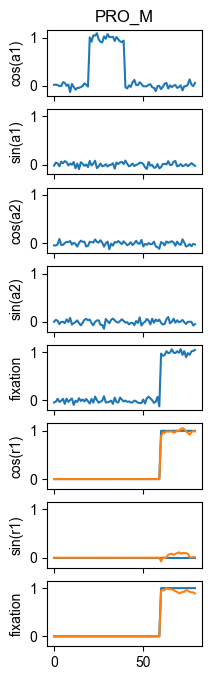

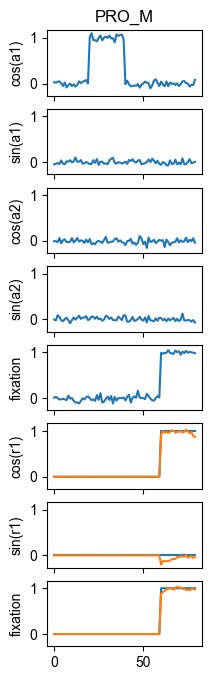

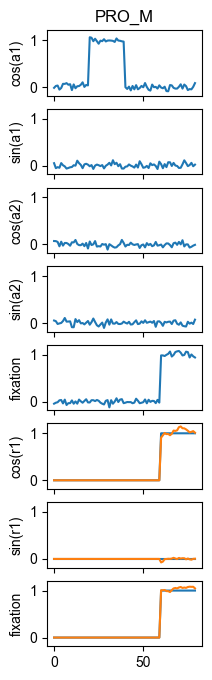

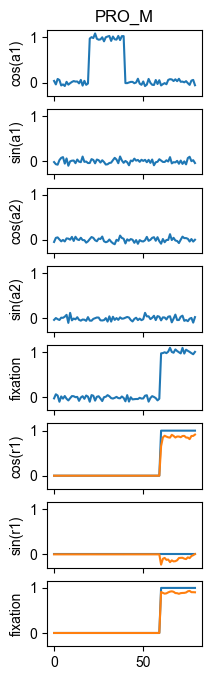

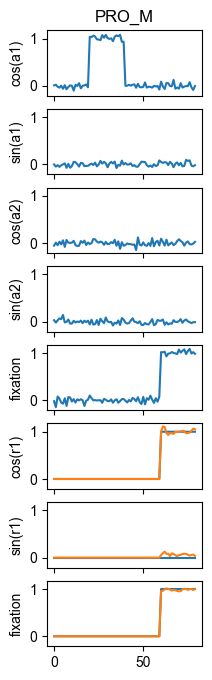

In [13]:
itask = 2
task = config['task_list'][itask]
epoch_str = task_epoch(task, epoch_type=config['epoch_type'])
fixed_x = 0

collected_z = []
collected_data = []

p_stay, min_Te, len_sfx = 0.95, 20, '' #config['p_stay'], config['min_Te']
p_stay, min_Te, len_sfx = 0.7, 20, '_pstay0pt7'

for itrial in range(10):
    x = fixed_x 
    # x = np.random.randint(config['nx'])
    sig_y = 0
    syz = generate_trial(task, x, config['z_list'], config['task_list'], config['sig_s'], sig_y,
                         p_stay, min_Te, config['d_stim'],
                         config['epoch_type'], config['fixation_type'],
                         info_type=config.get('info_type', 'z'),
                         min_Te_R=config.get('min_Te_R', None), p_stay_R=config.get('p_stay_R', None))
    syz = torch.tensor(syz[:, None, :], dtype=torch.float32).to(next(model.parameters()).device)
    s, y, z = syz[..., :dim_s], syz[..., dim_s:(dim_s + dim_y)], syz[..., (dim_s + dim_y):]
    with torch.no_grad():
        out, states = model(s, z)

    true_z = np.argmax(z.squeeze(1).cpu().numpy(), axis=1)
    true_data = states.squeeze(1).cpu().numpy()

    collected_z.append(true_z)
    collected_data.append(true_data)
    
    if itrial in [0, 1, 2, 3, 4]:
        fig, axes = plt.subplots(dim_s + dim_y, 1, figsize=(2, dim_s + dim_y), sharex=True, sharey=True)
        axes[0].set_title(task)
        for iax in range(dim_s):
            axes[iax].plot(s[:, :, iax].cpu().numpy())
        for iax in range(dim_y):
            axes[iax + dim_s].plot(y[:, :, iax].cpu().numpy())
            axes[iax + dim_s].plot(out[:, :, iax].cpu().numpy())
        ylabels = ['cos(a1)', 'sin(a1)', 'cos(a2)', 'sin(a2)', 'fixation',
                   'cos(r1)', 'sin(r1)', 'fixation']
        for iax in range(dim_s + dim_y):
            axes[iax].set_ylabel(ylabels[iax])

task_str = task.replace('PRO_', 'pro').replace('ANTI_', 'anti')
with open(f'./data/contextrnn_{task_str}_fixedx{fixed_x}{len_sfx}_collected_data.pkl', 'wb') as f:
    pickle.dump({'true_z': collected_z, 'true_x': None, 'true_y':collected_data}, f)

In [14]:
[len(cur) for cur in collected_data]

[80, 80, 80, 80, 80, 80, 80, 80, 80, 80]

In [10]:
with open(f'./data/contextrnn_proM_fixedx0_collected_data.pkl', 'rb') as f:
    data_dict = pickle.load(f)
true_z = data_dict['true_z']
y = data_dict['true_y']

In [12]:
z_all = np.concatenate(true_z)
y_all = np.concatenate(y)
print(z_all.shape, y_all.shape)

(935,) (935, 256)


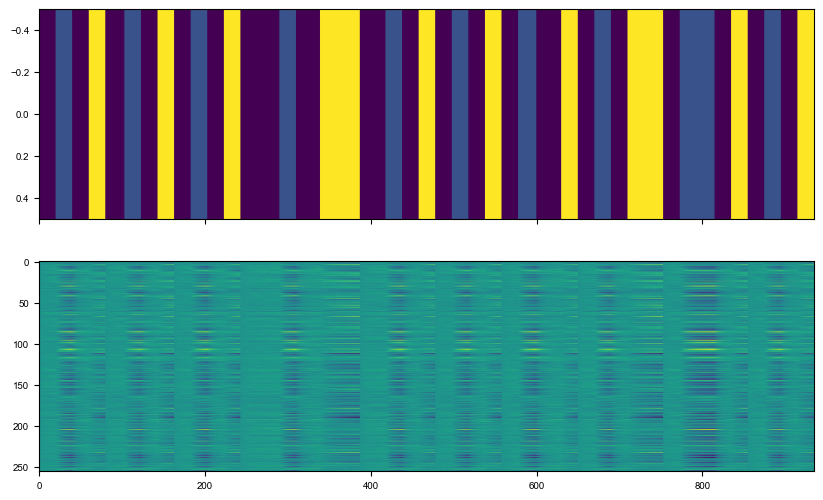

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].imshow(z_all[None, :], aspect='auto')
axes[1].imshow(y_all.T, aspect='auto')